# Importing dependencies

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Configuring graphs

In [2]:
plt.rc('font', **{'family':'serif', 'size': 10})
plt.rc('mathtext', **{'fontset':'cm'})
image_resolution = 600
fontsize_label = 12
fontsize_text = 18
fontsize_legend = 10
markers = ['o', 'v', 's', 'X', 'P', 'p', 'D', 'd', 'H', 'h', 'x', '+', '*', '1', '2', '|', '_']
marker_size = 6
cap_size = 3.0
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'teal', 'navy', 'maroon', 'lime']

# Thermophysical properties

In [3]:
def rho(temperature, salinity):
    a = [9.999e2, 2.034e-2, -6.162e-3, 2.261e-5, -4.657e-8]
    b = [8.020e2, -2.001, 1.677e-2, -3.060e-5, -1.613e-5]

    temperature_part = a[0] + a[1] * temperature
    temperature_part += a[2] * temperature * temperature
    temperature_part += a[3] * temperature * temperature * temperature
    temperature_part += a[4] * temperature * temperature * temperature * temperature

    salinity_part = b[0] * salinity
    salinity_part += b[1] * salinity * temperature
    salinity_part += b[2] * salinity * temperature * temperature
    salinity_part += b[3] * salinity * temperature * temperature * temperature
    salinity_part += b[4] * salinity * salinity * temperature * temperature

    return temperature_part + salinity_part

# Establishing directories

In [4]:
figures_dir = os.path.join('./figures/')

os.system('mkdir -p ' + figures_dir)

0

# Loading the cases

In [5]:
cases = pd.read_csv('cases_validation_manhas.csv')
cases = cases.rename(columns={
    'Tf_in': 'Feed temperature at the inlet (°C)',
    'Tc_in': 'Coolant temperature at the inlet (°C)',
    'P_ai gap': 'Vacuum pressure (Pa)',
    'Salinidade': 'Feed salinity at the inlet (g/L)',
    'area da membrana': 'Membrane area (m²)',
    'canais': 'Number of channels',
    'Fluxo experimental': 'Distilled water flux (L/m²h)',
    'incerteza fluxo': 'Distilled water flux uncertainty (L/m²h)',
    'Tf_out': 'Feed temperature at the outlet (°C)',
    'incerteza_tf_out': 'Feed temperature at the outlet uncertainty (°C)',
    'Tc_out': 'Coolant temperature at the outlet (°C)',
    'incerteza_tc_out': 'Coolant temperature at the outlet uncertainty (°C)',
    'Vazao': 'Flow rate (L/h)'
})

numeric_columns = [
    'Feed temperature at the inlet (°C)',
    'Coolant temperature at the inlet (°C)',
    'Vacuum pressure (Pa)',
    'Feed salinity at the inlet (g/L)',
    'Membrane area (m²)',
    'Number of channels',
    'Distilled water flux (L/m²h)',
    'Distilled water flux uncertainty (L/m²h)',
    'Feed temperature at the outlet (°C)',
    'Feed temperature at the outlet uncertainty (°C)',
    'Coolant temperature at the outlet (°C)',
    'Coolant temperature at the outlet uncertainty (°C)',
    'Flow rate (L/h)'
]
cases[numeric_columns] = cases[numeric_columns].apply(pd.to_numeric, errors='coerce')

cases['Case'] = cases['caso'].astype(str) + '-' + cases['sequencia'].astype(int).astype(str)
display(cases)


,caso,sequencia,Feed temperature at the inlet (°C),Coolant temperature at the inlet (°C),Flow rate (L/h),Vacuum pressure (Pa),Feed salinity at the inlet (g/L),Membrane area (m²),Number of channels,Distilled water flux (L/m²h),Distilled water flux uncertainty (L/m²h),Feed temperature at the outlet (°C),Feed temperature at the outlet uncertainty (°C),Coolant temperature at the outlet (°C),Coolant temperature at the outlet uncertainty (°C),Case
0,AS7,1,60,20,800,81325,35,7.20,6,4.30,0.12,NaN,NaN,50.3,0.8,AS7-1
1,AS7,2,60,30,800,81325,35,7.20,6,3.53,0.09,NaN,NaN,52.5,0.4,AS7-2
2,AS7,3,80,20,800,81325,35,7.20,6,7.07,0.19,NaN,NaN,66.2,0.4,AS7-3
3,AS7,4,80,30,800,81325,35,7.20,6,6.25,0.16,NaN,NaN,69.4,0.9,AS7-4
4,AS7,5,60,25,400,81325,35,7.20,6,2.07,0.11,NaN,NaN,53.5,0.6,AS7-5
5,AS7,6,60,25,1100,81325,35,7.20,6,4.86,0.23,NaN,NaN,49.6,0.6,AS7-6
6,AS7,7,80,25,400,81325,35,7.20,6,3.66,0.12,NaN,NaN,71.6,0.4,AS7-7
7,AS7,8,80,25,1100,81325,35,7.20,6,8.68,0.17,NaN,NaN,66.5,0.3,AS7-8
8,AS7,9,70,20,400,81325,35,7.20,6,3.09,0.08,NaN,NaN,61.0,0.4,AS7-9
9,AS7,10,70,20,1100,81325,35,7.20,6,7.10,0.19,NaN,NaN,55.7,0.4,AS7-10


# Running the cases

In [6]:
def salinity_equation(x, salinity, temperature):
    return rho(temperature, x) * x - salinity

In [7]:
results = pd.DataFrame(columns=[
    'Case', 'Permeate flux (L/m²h)', 'Exp. permeate flux (L/m²h)', 'Hot feedwater outlet temperature (°C)',
    'Exp. hot feedwater outlet temperature (°C)', 'Cold feedwater outlet temperature (°C)', 'Exp. cold feedwater outlet temperature (°C)',
    'Heat flux (W/m²)', 'Vapor heat flux (W/m²)', 'GOR', 'STECth', 'Thermal efficiency (%)'
])

for index, elem in cases.iterrows():
    hot_feedwater_inlet_temperature = elem['Feed temperature at the inlet (°C)']
    cold_feedwater_inlet_temperature = elem['Coolant temperature at the inlet (°C)']
    vacuum_pressure = -abs(elem['Vacuum pressure (Pa)'])

    initial_guess = elem['Feed salinity at the inlet (g/L)'] / 1000.0
    feed_salinity = fsolve(
        salinity_equation,
        initial_guess,
        args=(elem['Feed salinity at the inlet (g/L)'], elem['Feed temperature at the inlet (°C)'])
    )[0]
    cool_salinity = feed_salinity

    flow_rate = elem['Flow rate (L/h)']
    feed_mass_flow_rate = rho(hot_feedwater_inlet_temperature, feed_salinity) * flow_rate / 3600000.0
    cool_mass_flow_rate = rho(cold_feedwater_inlet_temperature, cool_salinity) * flow_rate / 3600000.0

    membrane_area = elem['Membrane area (m²)']
    number_channels = int(elem['Number of channels'])

    print('Salinity = ', str(elem['Feed salinity at the inlet (g/L)']), ' g/L')
    os.system('./bin/vagmd0Dmodel -entry_temperature_feed ' + str(hot_feedwater_inlet_temperature) +
              ' -entry_temperature_cool ' + str(cold_feedwater_inlet_temperature) +
              ' -feed_mass_flow_rate ' + str(feed_mass_flow_rate) +
              ' -cool_mass_flow_rate ' + str(cool_mass_flow_rate) +
              ' -vacuum_pressure ' + str(vacuum_pressure) +
              ' -entry_salinity_feed ' + str(feed_salinity) +
              ' -entry_salinity_cool ' + str(cool_salinity) +
              ' -membrane_area ' + str(membrane_area) +
              ' -number_channels ' + str(number_channels))

    results_file = pd.read_csv('./results/report.csv')
    latest_result = results_file.iloc[-1]

    mass_flux = latest_result.iloc[11]
    film_temperature = latest_result.iloc[4]
    hot_feedwater_outlet_temperature = latest_result.iloc[1]
    cold_feedwater_outlet_temperature = latest_result.iloc[2]
    heat_flux = latest_result.iloc[13]
    vapor_heat_flux = latest_result.iloc[15]
    GOR = latest_result.iloc[17]
    STECth = latest_result.iloc[19]
    thermal_efficiency = latest_result.iloc[18]

    new_row = pd.DataFrame([{
        'Case': elem['Case'],
        'Permeate flux (L/m²h)': 1000.0 * mass_flux / rho(film_temperature, 0.0),
        'Exp. permeate flux (L/m²h)': elem['Distilled water flux (L/m²h)'],
        'Hot feedwater outlet temperature (°C)': hot_feedwater_outlet_temperature,
        'Exp. hot feedwater outlet temperature (°C)': elem['Feed temperature at the outlet (°C)'],
        'Cold feedwater outlet temperature (°C)': cold_feedwater_outlet_temperature,
        'Exp. cold feedwater outlet temperature (°C)': elem['Coolant temperature at the outlet (°C)'],
        'Heat flux (W/m²)': heat_flux,
        'Vapor heat flux (W/m²)': vapor_heat_flux,
        'GOR': GOR,
        'STECth': STECth,
        'Thermal efficiency (%)': thermal_efficiency
    }])
    results = pd.concat([results, new_row], ignore_index=True)


Salinity =  35  g/L


/tmp/ipykernel_10922/1880593460.py:65: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L
Salinity =  35  g/L


In [8]:
display(results)

,Case,Permeate flux (L/m²h),Exp. permeate flux (L/m²h),Hot feedwater outlet temperature (°C),Exp. hot feedwater outlet temperature (°C),Cold feedwater outlet temperature (°C),Exp. cold feedwater outlet temperature (°C),Heat flux (W/m²),Vapor heat flux (W/m²),GOR,STECth,Thermal efficiency (%)
0,AS7-1,4.310885,4.30,31.502424,NaN,48.061344,50.3,3554.728459,2732.891928,1.803636,352.069383,76.880469
1,AS7-2,3.425813,3.53,38.232808,NaN,51.492844,52.5,2716.560552,2162.002621,2.007728,314.740202,79.586027
2,AS7-3,7.541042,7.07,34.831449,NaN,63.961749,66.2,5571.929445,4687.795815,2.298178,271.181987,84.132361
3,AS7-4,6.552588,6.25,41.849023,NaN,67.236719,69.4,4709.165800,4053.373501,2.503524,247.625749,86.074130
4,AS7-5,2.153291,2.07,31.401201,NaN,53.185369,53.5,1783.671054,1365.099405,3.159981,200.797968,76.533137
5,AS7-6,4.978970,4.86,36.804788,NaN,47.874388,49.6,3979.886523,3145.532006,1.488488,425.219362,79.035721
6,AS7-7,3.851109,3.66,33.462694,NaN,70.324173,71.6,2870.070313,2396.701652,3.898410,159.859873,83.506723
7,AS7-8,9.144076,8.68,41.160749,NaN,62.865593,66.5,6591.508503,5659.296857,1.891343,328.204035,85.857385
8,AS7-9,3.227548,3.09,28.586213,NaN,60.530561,61.0,2568.352453,2032.944789,3.378885,186.645686,79.153653
9,AS7-10,7.544341,7.10,36.057430,NaN,53.248979,55.7,5792.165212,4728.368877,1.616249,388.799499,81.633874


In [9]:
100.0 * (results['Permeate flux (L/m²h)'] - results['Exp. permeate flux (L/m²h)']) / results['Exp. permeate flux (L/m²h)']

0      0.253136
1     -2.951485
2      6.662542
3      4.841406
4      4.023740
5      2.447946
6      5.221566
7      5.346502
8      4.451379
9      6.258325
10    -0.439750
11     1.164883
12     2.807698
13     1.081450
14    -0.037533
15     6.380350
16     3.833291
17     9.018014
18     8.805901
19    -2.058128
20     6.151277
21     2.130543
22    12.225022
23     2.756706
24    12.278043
25     2.564168
26     6.419801
27     8.003372
28     7.393183
29     6.193259
30     0.942541
31     0.184850
32     6.163563
33     5.325308
34     0.634157
35     3.930781
36     1.726237
37     5.966902
38     1.839809
39     8.812595
40     4.790352
41     5.403347
42     2.476900
43     2.476900
44     2.476900
dtype: float64

# Plot the results for different salinities

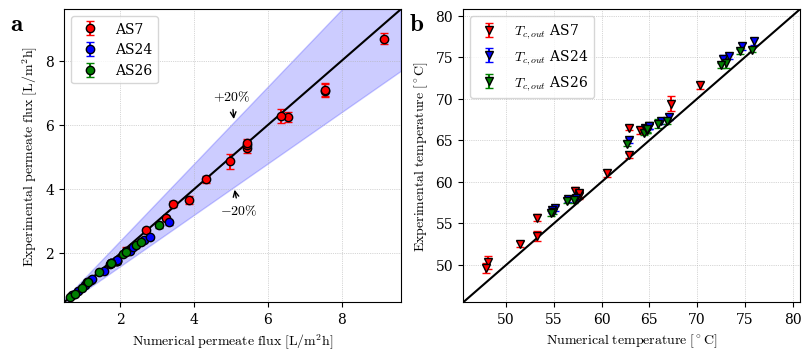

In [22]:
# 1. Extração de dados e criação de máscaras
flux_x = results['Permeate flux (L/m²h)'].to_numpy()
flux_y = results['Exp. permeate flux (L/m²h)'].to_numpy()
flux_err = cases['Distilled water flux uncertainty (L/m²h)'].to_numpy()
flux_mask = np.isfinite(flux_x) & np.isfinite(flux_y) & np.isfinite(flux_err)

min_mass_flux = 0.75 * np.nanmin([np.nanmin(flux_x[flux_mask]), np.nanmin(flux_y[flux_mask])])
max_mass_flux = 1.05 * np.nanmax([np.nanmax(flux_x[flux_mask]), np.nanmax(flux_y[flux_mask])])
mass_flux_line = np.linspace(min_mass_flux, max_mass_flux, 100)

hot_x = results['Hot feedwater outlet temperature (°C)'].to_numpy()
hot_y = results['Exp. hot feedwater outlet temperature (°C)'].to_numpy()
hot_err = cases['Feed temperature at the outlet uncertainty (°C)'].to_numpy()
hot_mask = np.isfinite(hot_x) & np.isfinite(hot_y) & np.isfinite(hot_err)

cold_x = results['Cold feedwater outlet temperature (°C)'].to_numpy()
cold_y = results['Exp. cold feedwater outlet temperature (°C)'].to_numpy()
cold_err = cases['Coolant temperature at the outlet uncertainty (°C)'].to_numpy()
cold_mask = np.isfinite(cold_x) & np.isfinite(cold_y) & np.isfinite(cold_err)

temperature_values = np.concatenate([hot_x[hot_mask], hot_y[hot_mask], cold_x[cold_mask], cold_y[cold_mask]])
min_temperature = 0.95 * np.nanmin(temperature_values)
max_temperature = 1.05 * np.nanmax(temperature_values)
temperature_line = np.linspace(min_temperature, max_temperature, 100)

# 2. Criação da figura e eixos
figval, axsval = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

# 3. Dicionário de cores por caso
case_colors = {
    'AS7': 'red',
    'AS24': 'blue',
    'AS26': 'green'
}

# --- 4. GRÁFICO 1: FLUXO PERMEADO (axsval[0]) ---
for prefix, color in case_colors.items():
    is_case = results['Case'].str.startswith(prefix).to_numpy()
    current_flux_mask = flux_mask & is_case
    
    if np.any(current_flux_mask):
        axsval[0].errorbar(
            flux_x[current_flux_mask],
            flux_y[current_flux_mask],
            yerr=flux_err[current_flux_mask],
            marker=markers[0], markersize=marker_size, markeredgecolor='black',
            color=color, capsize=cap_size, linestyle='None',
            label=prefix
        )

axsval[0].plot(mass_flux_line, mass_flux_line, color='black')
axsval[0].fill_between(mass_flux_line, 0.8 * mass_flux_line, 1.2 * mass_flux_line, color='blue', alpha=0.2)
axsval[0].annotate(r'$\mathrm{+20\%}$', xy=(mass_flux_line[50], 1.2 * mass_flux_line[50]), xytext=(-15, 15), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].annotate(r'$\mathrm{-20\%}$', xy=(mass_flux_line[50], 0.8 * mass_flux_line[50]), xytext=(-10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].set_xlim(min_mass_flux, max_mass_flux)
axsval[0].set_ylim(min_mass_flux, max_mass_flux)
axsval[0].grid(linestyle='dotted', linewidth=0.5)
axsval[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axsval[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')
axsval[0].legend(fontsize=fontsize_legend) 

# --- 5. GRÁFICO 2: TEMPERATURAS (axsval[1]) ---
for prefix, color in case_colors.items():
    is_case = results['Case'].str.startswith(prefix).to_numpy()
    
    # Temperatura Quente (hot) - Nenhuma label atribuída (logo, não vai para a legenda)
    current_hot_mask = hot_mask & is_case
    if np.any(current_hot_mask):
        axsval[1].errorbar(
            hot_x[current_hot_mask],
            hot_y[current_hot_mask],
            yerr=hot_err[current_hot_mask],
            marker=markers[0], markersize=marker_size, markeredgecolor='black',
            color=color, capsize=cap_size, linestyle='None'
        )
        
    # Temperatura Fria (cold) - Label formatada com o nome do caso atual
    current_cold_mask = cold_mask & is_case
    if np.any(current_cold_mask):
        axsval[1].errorbar(
            cold_x[current_cold_mask],
            cold_y[current_cold_mask],
            yerr=cold_err[current_cold_mask],
            marker=markers[1], markersize=marker_size, markeredgecolor='black',
            color=color, capsize=cap_size, linestyle='None',
            label=rf'$T_{{c,out}}$ {prefix}'  # Cria a label como: Tc,out AS7, etc.
        )

axsval[1].plot(temperature_line, temperature_line, color='black')
axsval[1].set_xlim(min_temperature, max_temperature)
axsval[1].set_ylim(min_temperature, max_temperature)

# Chama a legenda normalmente, pois as labels já foram definidas nos loops
axsval[1].legend(fontsize=fontsize_legend)

axsval[1].grid(linestyle='dotted', linewidth=0.5)
axsval[1].set_xlabel(r'$\mathrm{Numerical\ temperature\ [^\circ C]}$')
axsval[1].set_ylabel(r'$\mathrm{Experimental\ temperature\ [^\circ C]}$')

# 6. Finalização e salvamento
axsval[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axsval[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axsval[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axsval[1].transAxes, fontsize=fontsize_text, fontweight='bold')

figval.savefig(figures_dir + 'validation_salinity.svg', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)

In [19]:
# Quantidade de pontos no gráfico de fluxo de permeado (Gráfico a)
qtd_fluxo = flux_mask.sum()
print(f"Pontos plotados no gráfico de fluxo de permeado: {qtd_fluxo}")

# Quantidade de pontos no gráfico de temperatura (Gráfico b)
qtd_hot = hot_mask.sum()
qtd_cold = cold_mask.sum()
print(f"Pontos Tf,out plotados no gráfico de temperatura: {qtd_hot}")
print(f"Pontos Tc,out plotados no gráfico de temperatura: {qtd_cold}")
print(f"Total de pontos no gráfico de temperatura: {qtd_hot + qtd_cold}")

Pontos plotados no gráfico de fluxo de permeado: 45
Pontos Tf,out plotados no gráfico de temperatura: 0
Pontos Tc,out plotados no gráfico de temperatura: 45
Total de pontos no gráfico de temperatura: 45


In [12]:
import os

# 1. Adiciona uma nova coluna com o desvio percentual absoluto
results['Deviation (%)'] = 100.0 * abs(results['Permeate flux (L/m²h)'] - results['Exp. permeate flux (L/m²h)']) / results['Exp. permeate flux (L/m²h)']

# 2. Cria as máscaras para separar os dados (<= 20% e > 20%)
mask_within_20 = results['Deviation (%)'] <= 20.0
mask_above_20 = results['Deviation (%)'] > 20.0

# 3. Separa os resultados em dois DataFrames distintos
df_within_20 = results[mask_within_20]
df_above_20 = results[mask_above_20]

# 4. Garante que o diretório existe e exporta para CSV
os.makedirs('./results', exist_ok=True)
df_within_20.to_csv('./results/desvios_ate_20.csv', index=False)
df_above_20.to_csv('./results/desvios_acima_de_20.csv', index=False)

print(f"Arquivos CSV gerados com sucesso!")
print(f"-> Casos com desvio de até 20%: {len(df_within_20)}")
print(f"-> Casos com desvio maior que 20%: {len(df_above_20)}")

Arquivos CSV gerados com sucesso!
-> Casos com desvio de até 20%: 45
-> Casos com desvio maior que 20%: 0


In [13]:
# 3. Recalcula os limites do fluxo de permeado
min_mass_flux_final = 0.75 * np.nanmin([np.nanmin(flux_x[final_mask]), np.nanmin(flux_y[final_mask])])
max_mass_flux_final = 1.05 * np.nanmax([np.nanmax(flux_x[final_mask]), np.nanmax(flux_y[final_mask])])

# AJUSTE: Linha base parte de 0 até um valor muito maior, cruzando toda a tela
mass_flux_line_final = np.linspace(0, max_mass_flux_final * 1.5, 100)

# 4. Recalcula os limites de temperatura
temp_values_final = np.concatenate([
    hot_x[final_mask], hot_y[final_mask], 
    cold_x[final_mask], cold_y[final_mask]
])
min_temp_final = 0.95 * np.nanmin(temp_values_final)
max_temp_final = 1.05 * np.nanmax(temp_values_final)

# AJUSTE: Fazemos o mesmo para a reta de temperaturas
temp_line_final = np.linspace(0, max_temp_final * 1.5, 100)

# 5. Configura a figura com dois gráficos (1 linha, 2 colunas)
fig_final, axs_final = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

# ----------------- Gráfico a: Fluxo de Permeado (Desvio <= 20%) -----------------
axs_final[0].errorbar(
    flux_x[final_mask],
    flux_y[final_mask],
    yerr=flux_err[final_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, linestyle='None'
)
axs_final[0].plot(mass_flux_line_final, mass_flux_line_final, color='black')
axs_final[0].fill_between(mass_flux_line_final, 0.8 * mass_flux_line_final, 1.2 * mass_flux_line_final, color='blue', alpha=0.2)

# AJUSTE: Coordenadas calculadas dinamicamente com base na área visível
# Pegamos pontos que estão a 30% (para o -20%) e a 70% (para o +20%) da janela visível
x_range = max_mass_flux_final - min_mass_flux_final
x_down = min_mass_flux_final + 0.30 * x_range
x_up = min_mass_flux_final + 0.70 * x_range

axs_final[0].annotate(r'$\mathrm{+20\%}$', xy=(x_up, 1.2 * x_up), 
                      xytext=(-45, 5), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axs_final[0].annotate(r'$\mathrm{-20\%}$', xy=(x_down, 0.8 * x_down), 
                      xytext=(0, -30), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

# AJUSTE: Trava os eixos firmemente para recortar as sobras da linha e evitar margens em branco
axs_final[0].set_xlim(min_mass_flux_final, max_mass_flux_final)
axs_final[0].set_ylim(min_mass_flux_final, max_mass_flux_final)
axs_final[0].grid(linestyle='dotted', linewidth=0.5)
axs_final[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axs_final[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')

# ----------------- Gráfico b: Temperaturas -----------------
axs_final[1].errorbar(
    hot_x[final_mask],
    hot_y[final_mask],
    yerr=hot_err[final_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[1], capsize=cap_size, label=r'$T_{f,out}$', linestyle='None'
)
axs_final[1].errorbar(
    cold_x[final_mask],
    cold_y[final_mask],
    yerr=cold_err[final_mask],
    marker=markers[1], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, label=r'$T_{c,out}$', linestyle='None'
)
axs_final[1].plot(temp_line_final, temp_line_final, color='black')
axs_final[1].set_xlim(min_temp_final, max_temp_final)
axs_final[1].set_ylim(min_temp_final, max_temp_final)
axs_final[1].legend(fontsize=fontsize_legend)
axs_final[1].grid(linestyle='dotted', linewidth=0.5)
axs_final[1].set_xlabel(r'$\mathrm{Numerical\ temperature\ [^\circ C]}$')
axs_final[1].set_ylabel(r'$\mathrm{Experimental\ temperature\ [^\circ C]}$')

# ----------------- Formatação Final e Salvamento -----------------
axs_final[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axs_final[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axs_final[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axs_final[1].transAxes, fontsize=fontsize_text, fontweight='bold')

fig_final.savefig(figures_dir + 'validation_strict_20_percent_fixed.svg', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)

plt.show()

# 6. Imprime a quantidade
qtd_final = final_mask.sum()
print(f"Total de experimentos com informações completas e desvio <= 20%: {qtd_final}")
print(f"-> O gráfico 'a' possui {qtd_final} pontos plotados.")
print(f"-> O gráfico 'b' possui {qtd_final * 2} pontos plotados ({qtd_final} de Tf,out e {qtd_final} de Tc,out).")

NameError: name 'final_mask' is not defined

In [ ]:
import os

# Filtra o DataFrame de resultados usando a máscara final (completos e <= 20% desvio)
df_casos_grafico = results[final_mask]

# Garante que o diretório existe e exporta para CSV
os.makedirs('./results', exist_ok=True)
caminho_csv = './results/casos_grafico_final.csv'
df_casos_grafico.to_csv(caminho_csv, index=False)

print(f"\nArquivo '{caminho_csv}' gerado com sucesso!")
print(f"Total de linhas exportadas: {len(df_casos_grafico)}")


Arquivo './results/casos_grafico_final.csv' gerado com sucesso!
Total de linhas exportadas: 41
